 # Filtro pasa alto
 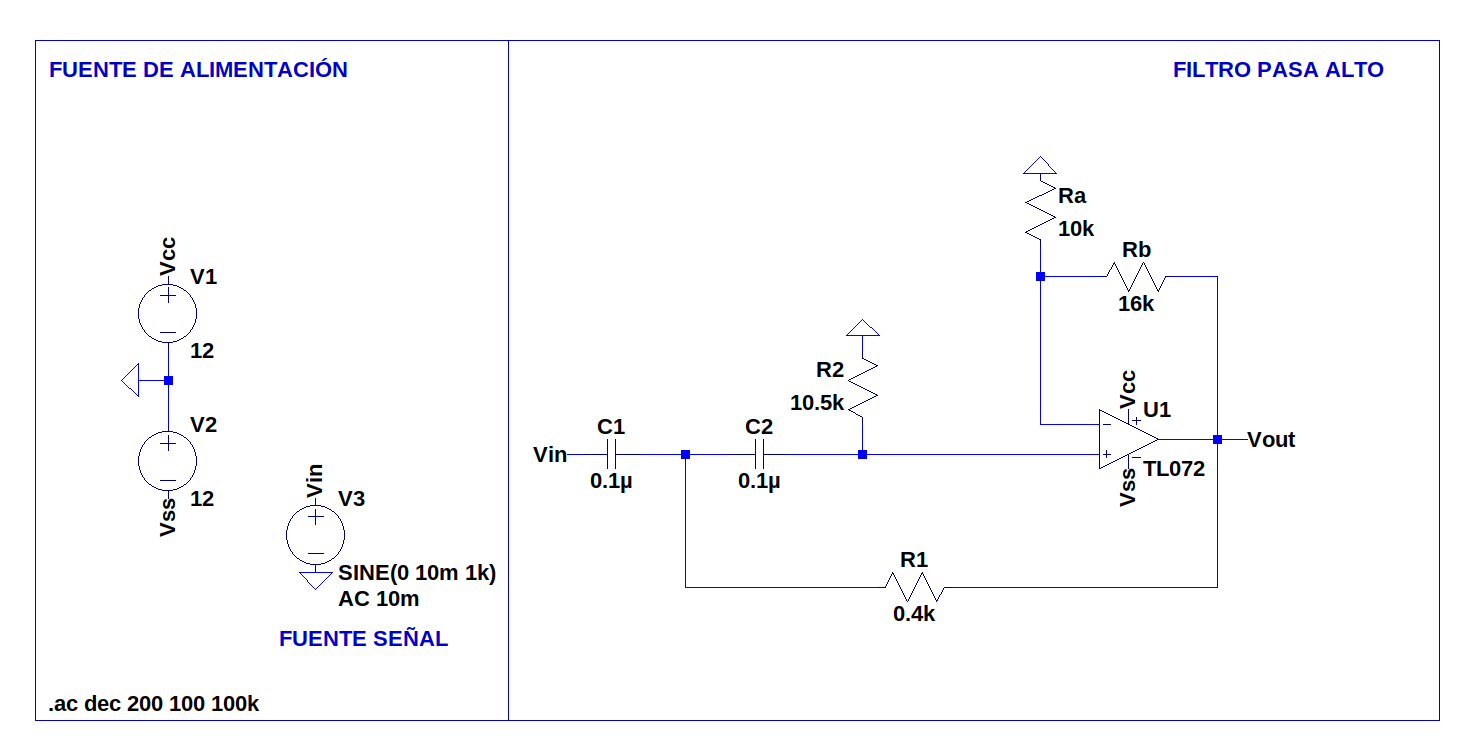

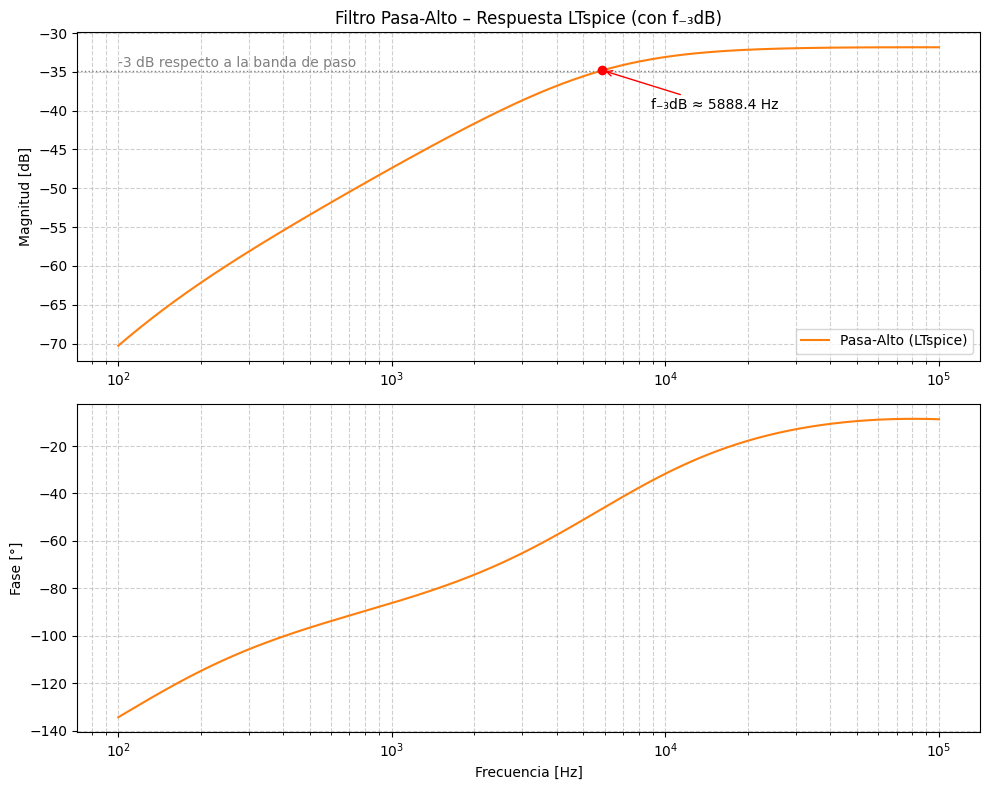

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
#  Lectura del archivo exportado desde LTspice
#  Formato:  Freq   Re,Im
# ======================================================

def load_ltspice_complex(filename):
    freq = []
    re_v = []
    im_v = []

    with open(filename, "r") as f:
        next(f)  # saltear encabezado (Freq.   V(vout))
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            # Frecuencia
            f_val = float(parts[0])

            # Segundo campo: "Re,Im"
            comp = parts[1]
            re_str, im_str = comp.split(',')
            re_val = float(re_str)
            im_val = float(im_str)

            freq.append(f_val)
            re_v.append(re_val)
            im_v.append(im_val)

    freq = np.array(freq)
    re_v = np.array(re_v)
    im_v = np.array(im_v)

    # Magnitud y fase
    v_c = re_v + 1j * im_v
    mag_db = 20 * np.log10(np.abs(v_c))
    phase_deg = np.angle(v_c, deg=True)

    return freq, mag_db, phase_deg


# ======================================================
#  Bode PASA-ALTO con marcador de -3 dB (sin normalizar)
# ======================================================

filename = "filtro_pa.txt"   # <-- poné el nombre de tu txt acá

freq, mag_db, phase_deg = load_ltspice_complex(filename)

# Nivel máximo (banda de paso)
max_gain = np.max(mag_db)
target = max_gain - 3.0   # -3 dB respecto al máximo

# Para pasa-alto: buscamos el PRIMER punto que SUPERA ese nivel
idx_3db = np.where(mag_db >= target)[0][0]
f_3db = freq[idx_3db]
mag_3db = mag_db[idx_3db]

plt.figure(figsize=(10, 8))

# ---------------------------------------
# MAGNITUD
# ---------------------------------------
plt.subplot(2, 1, 1)
plt.semilogx(freq, mag_db, label="Pasa-Alto (LTspice)", color="tab:orange")

# Línea horizontal -3 dB
plt.axhline(target, color='gray', linestyle=':', linewidth=1)
plt.text(freq[0], target + 0.5,
         "-3 dB respecto a la banda de paso",
         color="gray")

# Punto f_-3dB
plt.semilogx(f_3db, mag_3db, 'ro')
plt.annotate(f"f₋₃dB ≈ {f_3db:.1f} Hz",
             xy=(f_3db, mag_3db),
             xytext=(1.5*f_3db, mag_3db - 5),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Magnitud [dB]")
plt.title("Filtro Pasa-Alto – Respuesta LTspice (con f₋₃dB)")
plt.legend()

# ---------------------------------------
# FASE
# ---------------------------------------
plt.subplot(2, 1, 2)
plt.semilogx(freq, phase_deg, color="tab:orange")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Fase [°]")
plt.xlabel("Frecuencia [Hz]")

plt.tight_layout()
plt.show()
